In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import dill

In [43]:
with open ('threshold_testing_results_v0.dill', 'rb') as f:
    results_abs = dill.load(f)

In [44]:
with open ('threshold_testing_results_v1.dill', 'rb') as f:
    results_prop = dill.load(f)

In [3]:
results.keys()

dict_keys([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

In [5]:
results_05 = pd.DataFrame(results[0.05])

In [6]:
results_05.head()

,clustering,path_length,swp
0,0.274056,3.607438,0.628946
1,0.325242,3.230997,0.546110
2,0.477409,2.365464,0.292893
3,0.342207,3.100196,0.544979
4,0.308067,3.286177,0.580410


In [4]:
results[0.05].keys()

dict_keys(['clustering', 'path_length', 'swp'])

In [49]:
# Turn results into long df
rows = []
for threshold, metrics in results_prop.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_prop = pd.long_dataframe = pd.DataFrame(rows)
df_prop['method'] = 'proportional'

In [50]:
# Turn results into long df
rows = []
for threshold, metrics in results_abs.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_abs = pd.long_dataframe = pd.DataFrame(rows)
df_abs['method'] = 'absolute'

In [54]:
df = pd.concat([df_abs, df_prop], axis=0)
df.head()

,threshold,metric,value,method
0,0.05,clustering,0.274056,absolute
1,0.05,clustering,0.325242,absolute
2,0.05,clustering,0.477409,absolute
3,0.05,clustering,0.342207,absolute
4,0.05,clustering,0.308067,absolute


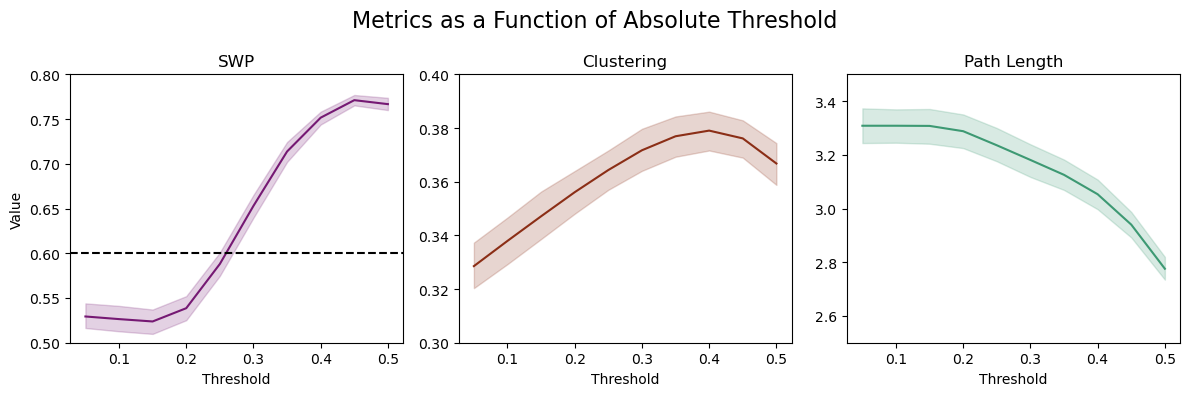

In [35]:
# Plot clustering, path length, and SWP at all threshold levels -- ABSOLUTE THRESHOLD
metrics = ['swp', 'clustering', 'path_length']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# SWP
sns.lineplot(data=df[df['metric'] == 'swp'], x='threshold', y='value',
             errorbar=('ci', 95), color=sns.xkcd_rgb['darkish purple'], ax=axes[0])
axes[0].axhline(y=0.6, color='black', linestyle='--')
axes[0].set_title('SWP')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0.5, 0.8)

# Clustering
sns.lineplot(data=df[df['metric'] == 'clustering'], x='threshold', y='value',
             errorbar=('ci', 95), color=sns.xkcd_rgb['red brown'], ax=axes[1])
axes[1].set_title('Clustering')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel(None)
axes[1].set_ylim(0.3, 0.4)

# Path length
sns.lineplot(data=df[df['metric'] == 'path_length'], x='threshold', y='value',
             errorbar=('ci', 95), color=sns.xkcd_rgb['ocean green'], ax=axes[2])
axes[2].set_title('Path Length')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel(None)
axes[2].set_ylim(2.5, 3.5)

plt.suptitle('Metrics as a Function of Absolute Threshold', fontsize=16)

plt.tight_layout()
plt.savefig('abs_threshold_metrics.png')
plt.show()

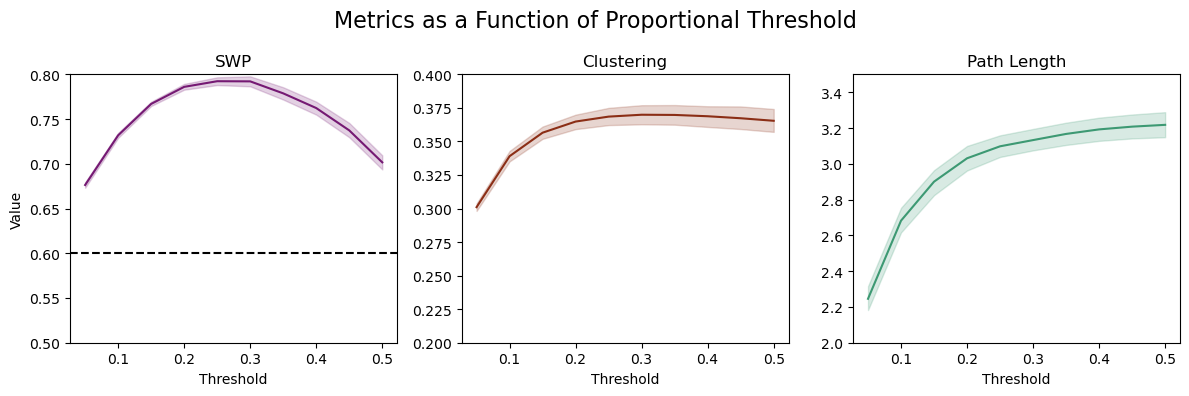

In [42]:
# Plot clustering, path length, and SWP at all threshold levels -- PROPORTIONAL THRESHOLD
metrics = ['swp', 'clustering', 'path_length']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# SWP
sns.lineplot(data=df[df['metric'] == 'swp'], x='threshold', y='value',
             errorbar=('ci', 95), color=sns.xkcd_rgb['darkish purple'], ax=axes[0])
axes[0].axhline(y=0.6, color='black', linestyle='--')
axes[0].set_title('SWP')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0.5, 0.8)

# Clustering
sns.lineplot(data=df[df['metric'] == 'clustering'], x='threshold', y='value',
             errorbar=('ci', 95), color=sns.xkcd_rgb['red brown'], ax=axes[1])
axes[1].set_title('Clustering')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel(None)
axes[1].set_ylim(0.2, 0.4)

# Path length
sns.lineplot(data=df[df['metric'] == 'path_length'], x='threshold', y='value',
             errorbar=('ci', 95), color=sns.xkcd_rgb['ocean green'], ax=axes[2])
axes[2].set_title('Path Length')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel(None)
axes[2].set_ylim(2, 3.5)

plt.suptitle('Metrics as a Function of Proportional Threshold', fontsize=16)

plt.tight_layout()
plt.savefig('prop_threshold_metrics.png')
plt.show()

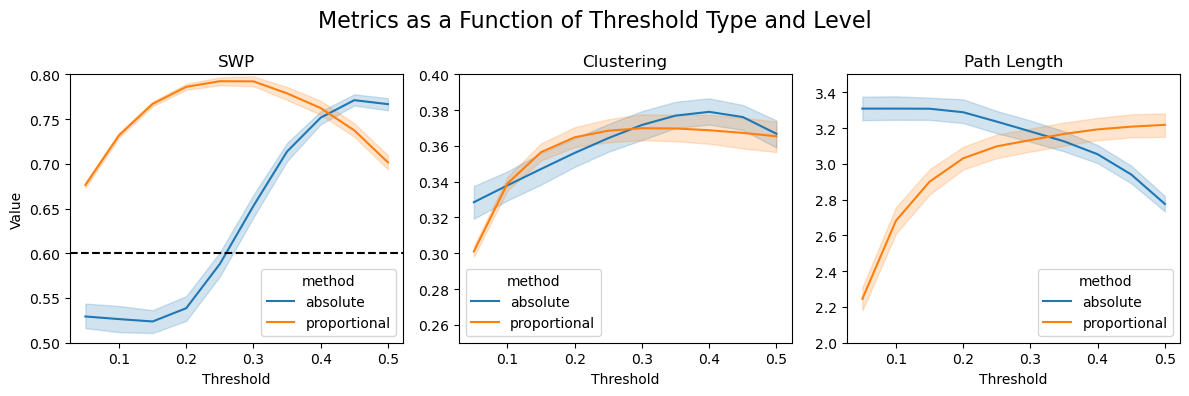

In [61]:
# Plot clustering, path length, and SWP at all threshold levels -- COMBINED
metrics = ['swp', 'clustering', 'path_length']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# SWP
sns.lineplot(data=df[df['metric'] == 'swp'], x='threshold', y='value',
             errorbar=('ci', 95), hue='method', ax=axes[0])
axes[0].axhline(y=0.6, color='black', linestyle='--')
axes[0].set_title('SWP')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0.5, 0.8)

# Clustering
sns.lineplot(data=df[df['metric'] == 'clustering'], x='threshold', y='value',
             errorbar=('ci', 95), hue='method', ax=axes[1])
axes[1].set_title('Clustering')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel(None)
axes[1].set_ylim(0.25, 0.4)

# Path length
sns.lineplot(data=df[df['metric'] == 'path_length'], x='threshold', y='value',
             errorbar=('ci', 95), hue='method', ax=axes[2])
axes[2].set_title('Path Length')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel(None)
axes[2].set_ylim(2, 3.5)

plt.suptitle('Metrics as a Function of Threshold Type and Level', fontsize=16)

plt.tight_layout()
plt.savefig('combined_threshold_metrics.png')
plt.show()